# Horsehead Nebula FITS Image

## Downloading the file and extracting data

In [73]:
# Here, we import the requisite modules for downloading and extracting the image.
from astropy.utils.data import download_file
from astropy.io import fits

# Here, we import other modules required for calculations and visualisations
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# This statement downloads the image file and stores its path
image_file = download_file(
    'http://www.astropy.org/astropy-data/tutorials/FITS-images/HorseHead.fits',
    cache=True
)

# This section opens the file and extracts some info, the header and the image data
hdu_list = fits.open(image_file)

hdu_list.info()
image_header = hdu_list[0].header
image_data = hdu_list[0].data

hdu_list.close()

Filename: C:\Users\HR1000TU\.astropy\cache\download\url\217b4fe80e6f349ef703ceed7e0be888\contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     161   (891, 893)   int16   
  1  er.mask       1 TableHDU        25   1600R x 4C   [F6.2, F6.2, F6.2, F6.2]   


## Some information on the extracted data

### The image header

In [74]:
# printing the image header
image_header

SIMPLE  =                    T /FITS: Compliance                                
BITPIX  =                   16 /FITS: I*2 Data                                  
NAXIS   =                    2 /FITS: 2-D Image Data                            
NAXIS1  =                  891 /FITS: X Dimension                               
NAXIS2  =                  893 /FITS: Y Dimension                               
EXTEND  =                    T /FITS: File can contain extensions               
DATE    = '2014-01-09        '  /FITS: Creation Date                            
ORIGIN  = 'STScI/MAST'         /GSSS: STScI Digitized Sky Survey                
SURVEY  = 'SERC-ER '           /GSSS: Sky Survey                                
REGION  = 'ER768   '           /GSSS: Region Name                               
PLATEID = 'A0JP    '           /GSSS: Plate ID                                  
SCANNUM = '01      '           /GSSS: Scan Number                               
DSCNDNUM= '00      '        

#### Some keywords in the header
* NAXIS1 
    * Number of pixels along the first axis (x-axis) i.e the width
* NAXIS2
    * Number of pixels along the second axis (y-axis) i.e the height
* DATE-OBS
    * The date and time(UTC) of observation of this image in YYYY-MM-DDT:MM:SS.sss format, typically taken at the start of exposure
* TELESCOP
    * The specific observatory, telescope or instrument platform used for the observation
* FILTER
    * Name of the selected optical filter, if a filter was used
* EQUINOX
    * The equinox(epoch) of the celestial coordinate system (to correct for the changing positions of stars due to, for example, precession of Earth's axis)
* CRVAL1
    * First coordinate (here, Right Ascension or RA) of the reference pixel of the image
* CRVAL2
    * Second coordinate (here, Declination or Dec) of the reference pixel of the image
* DATAMIN
    * The minimum valid physical value represented by the array, excluding special values like NULL
* DATAMAX
    * The maxmum valid physical value represented by the array, excluding special values like NULL

### The image data

In [75]:
# printing the image data
image_data

array([[ 7201,  6642,  6642, ...,  9498,  9498, 10057],
       [ 6642,  6363,  6642, ..., 10057, 10616, 10616],
       [ 6922,  6642,  6922, ..., 10337, 11175, 10616],
       ...,
       [ 5412,  5132,  5412, ..., 13000, 12580, 12021],
       [ 5796,  5517,  5796, ..., 12546, 12546, 11987],
       [ 5796,  5796,  6076, ..., 11987, 12546, 12546]],
      shape=(893, 891), dtype='>i2')

## Calculating some key information about the image

In [76]:
# This section calculates some information about the array representation the image

shape = image_data.shape          # the dimensions of the image (equal to NAXIS2 and NAXIS1)
min_value = np.min(image_data)    # minimum physical pixel value (equal to DATAMIN)
max_value = np.max(image_data)    # maximum Physical pixel value (equal to DATAMAX)
mean_value = np.mean(image_data)  # mean of the physical pixel values 
std_dev = np.std(image_data)      # standard deviation of the physical pixel values

print(
    f"Image Info :-\n",
    f"Shape : {shape}",
    f"Minimum Pixel Value : {min_value}",
    f"Maximum Pixel Value : {max_value}",
    f"Mean Pixel Value : {mean_value}",
    f"Standard Deviation : {std_dev}",
    sep="\n"
    )

Image Info :-

Shape : (893, 891)
Minimum Pixel Value : 3759
Maximum Pixel Value : 22918
Mean Pixel Value : 9831.481676287574
Standard Deviation : 3032.3927542049046


## Plotting the image

### Using gray colour map

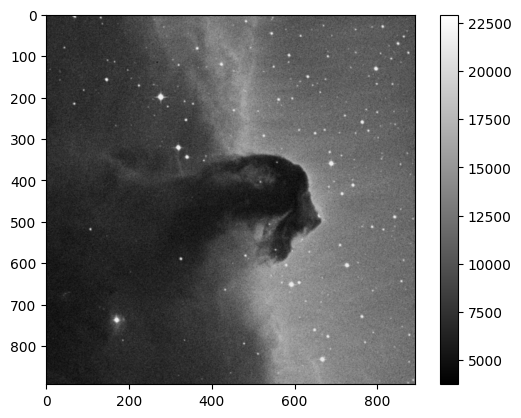

In [77]:
# This section plots the image in grayscale

plt.imshow(image_data, cmap='gray') # the image
plt.colorbar()                      # the colour bar

### Using magma colour map

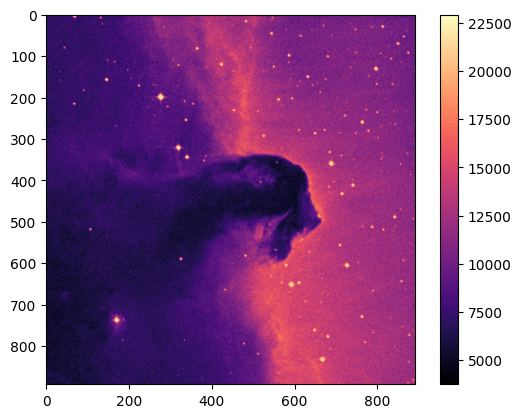

In [78]:
# same as above but in magma instead of grayscale

plt.imshow(image_data, cmap='magma')
plt.colorbar()

### Using Log-Normal scaling

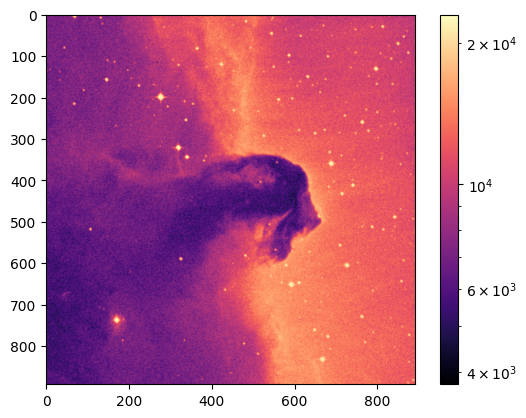

In [79]:
# This section plots the same image but in a logarithmic colour scale which is often used by astronomers

plt.imshow(image_data, cmap='magma', norm=LogNorm()) # Using a LogNorm object from matplotlib
plt.colorbar()

As we can see, logarithmic scaling is making many dimmer stars and other very dim objects more visible. This is because, logarithmic scaling heavily 'squashes' the range of values. A range of, say 10<sup>2</sup> - 10<sup>4</sup> will become a range of 2 - 4.

Astronomers often work with values ranging multiple orders of magnitude. For example, stellar luminosities can range from around 10<sup>-4</sup> to 10<sup>6</sup> solar luminosities (L<sub>sun</sub>) where 1L<sub>sun</sub> = 3.828 x 10<sup>26</sup> Watts.

This is why astronomors often use logarithmic visualisation. It helps in seeing the less prominant features which can be overshadowed by the brightest objects when using linear scaling.

### Histogram of pixel values

In [80]:
# a flattened 1D version of the 2D image value array is made

image_data.flatten()

array([ 7201,  6642,  6642, ..., 11987, 12546, 12546],
      shape=(795663,), dtype='>i2')

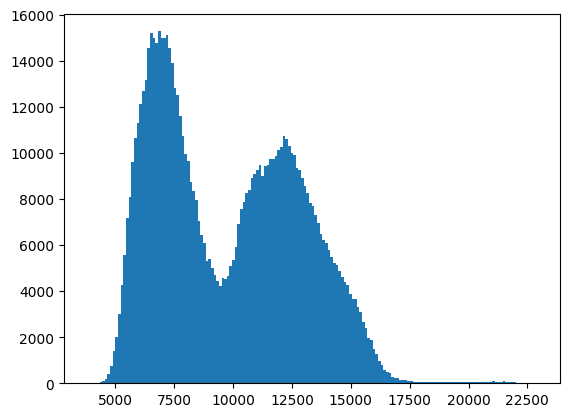

In [81]:
# Here, a histogram of all the pixel values of the image is created

histogram = plt.hist(image_data.flatten(), bins='auto')